## **Project Title**  
**Tourism Experience Analytics: Prediction and Recommendation System**

## **Project Overview**  
The tourism industry generates large amounts of data from user visits, ratings, and travel behavior. However, this data is often underutilized for improving user experience and business decision-making.

This project focuses on analyzing tourism data to build an end-to-end analytics system that combines **regression, classification, and recommendation models**. The system predicts user satisfaction (ratings), classifies user travel behavior (visit mode), and provides personalized attraction recommendations based on user preferences and historical interactions.

The final outcome is an interactive analytics solution that helps tourism platforms deliver personalized experiences, improve customer retention, and support data-driven business strategies.

## **Business Use Cases**  
- **Personalized Recommendations:** Suggest attractions tailored to user preferences and past visits.  
- **User Satisfaction Prediction:** Predict attraction ratings to estimate user satisfaction in advance.  
- **Customer Segmentation:** Classify users by visit mode (Business, Family, Couples, etc.) for targeted marketing.  
- **Tourism Insights:** Identify popular attractions, regions, and travel trends to support strategic planning.

## **STEP 1: Data Loading**

The first step is to load the dataset which is the base for the Machine Learning

In [2]:
import pandas as pd

# Storing the dataset in the variable data_path
data_path = "../dataset/final_dataset.csv"
final_df = pd.read_csv(data_path) # Converting the dataset into CSV file

final_df.shape

(52930, 28)

# **Step 2: Data Cleaning**
Data cleaning is an essential step to ensure the dataset is reliable and ready for analysis and modeling.
Real-world data often contains missing values and inconsistencies that can negatively impact insights and machine learning performance.

## **2.1 Handling The Missing Values**

Handling missing values is a crucial part of data cleaning, as incomplete data can lead to incorrect analysis and poor model performance.
Missing values may occur due to system limitations, user behavior, or data integration from multiple sources.

In [3]:
# Checking the missing values
final_df.isna().sum().sort_values(ascending=False)

Country                  8
CityId                   8
RegionId_region          8
Region                   8
RegionId_y               8
CountryId_country        8
CountryId_y              8
CityName                 8
ContinentId_y            8
CountryId_x              0
AttractionTypeId         0
VisitYear                0
VisitMonth               0
VisitMode_y              0
VisitModeId              0
AttractionType           0
AttractionAddress        0
Attraction               0
AttractionCityId         0
RegionId_x               0
Continent                0
ContinentId_continent    0
VisitMode_x              0
UserId                   0
AttractionId             0
Rating                   0
ContinentId_x            0
TransactionId            0
dtype: int64

In [4]:
# Storing the columns with the missing values in an list "geo_columns"
geo_columns = [
    'CityId', 'CityName',
    'Country', 'CountryId_y', 'CountryId_country',
    'Region', 'RegionId_y', 'RegionId_region',
    'ContinentId_y'
]

# Filling the missing values for the coulmns with "Unknown"
for col in geo_columns:
    if col in final_df.columns:
        final_df[col] = final_df[col].fillna('Unknown')

# Verifying the missing values
print("Missing values after handling:")
print(final_df.isnull().sum())

Missing values after handling:
TransactionId            0
UserId                   0
VisitYear                0
VisitMonth               0
VisitMode_x              0
AttractionId             0
Rating                   0
ContinentId_x            0
RegionId_x               0
CountryId_x              0
CityId                   0
CityName                 0
CountryId_y              0
CountryId_country        0
Country                  0
RegionId_y               0
ContinentId_continent    0
Continent                0
AttractionCityId         0
AttractionTypeId         0
Attraction               0
AttractionAddress        0
AttractionType           0
VisitModeId              0
VisitMode_y              0
Region                   0
RegionId_region          0
ContinentId_y            0
dtype: int64


## **2.2 Fixing the Data Quality**

After handling missing values, the next step is to ensure data consistency and correctness.
Data quality issues such as inconsistent naming, duplicate records, and invalid values can distort analysis and negatively impact model performance.

In [5]:
# Fixing the inconsistent column 'CitiyName'
# Standardising the text - lowercase, strip spaces, title case
final_df['CityName'] = (
    final_df['CityName']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.title()
)


# Storing the shape (no of columns and rows) before removing duplicate records in the variable "before" 
before = final_df.shape[0]

# Removing the duplicates
final_df = final_df.drop_duplicates(subset='TransactionId')

# Storing the shape (no of columns and rows) after removing duplicate records in the variable "after" 
after = final_df.shape[0]
print(f"Duplicate transactions removed: {before - after}") # Calculating the number of duplicate rows removed


# Removing invalid rating because the rating should be between 1 and 5
final_df = final_df[(final_df['Rating'] >= 1) & (final_df['Rating'] <= 5)]

# Validating the updates
print("Final Dataset Shape after Data Quality Fixes:", final_df.shape)
print("Rating Range:", final_df['Rating'].min(), "-", final_df['Rating'].max())

Duplicate transactions removed: 0
Final Dataset Shape after Data Quality Fixes: (52930, 28)
Rating Range: 1 - 5


## **Step 3: Data Preprocessing**

 ## **3.1: Feature Engineering**

 Feature engineering transforms raw data into meaningful inputs that help models learn patterns more effectively. By creating user-level, attraction-level, and time-based features, we capture behavior, popularity, and temporal trends that are not directly visible in the original data. This step improves model accuracy, interpretability, and overall performance.

In [6]:
# Creating a table which contains user features (user average rating and user total visits)
user_features = final_df.groupby("UserId").agg(
    user_avg_rating=("Rating", "mean"),
    user_total_visits=("Rating", "count")
).reset_index()



# Merging the user_features table with the main dataset (final_df)
final_df = final_df.merge(user_features, on="UserId", how="left")


# Creating a table which contains attraction features (attraction_average_rating and attraction_popularity)
attraction_features = final_df.groupby("AttractionId").agg(
    attraction_avg_rating=("Rating", "mean"),
    attraction_popularity=("Rating", "count")
).reset_index()



# Merging the attraction_features table with the main dataset (final_df)
final_df = final_df.merge(attraction_features, on="AttractionId",how="left")


# Creating function to map season to month
def get_season(month):
    if month in [12, 1, 2]: # This block will be executed if the month is 12, 1 or 2 (December, January or February) and returns Winter
        return 'Winter'
    elif month in [3, 4, 5]: # This block will be executed if the month is 3, 4 or 5 (March, April or May) and returns Summer
        return 'Summer'
    elif month in [6, 7, 8]: # This block will be executed if the month is 6, 7 or 8 (June, July or August) and returns Spring
        return 'Spring'
    else:
        return 'Fall' # This block will be executed if the month is 9, 10 or 11 (Septemberr, October or November) and returns Fall

# Create an new column 'season' and store every month's season after applying the above function
final_df['season'] = final_df['VisitMonth'].apply(get_season)

# Create a new column "year_trend" and stores a relative time feature used to measure recency
final_df['year_trend'] = final_df['VisitYear'] - final_df['VisitYear'].min()

# Selecting the columns we require from the dataset
x = ["TransactionId", "UserId", "VisitYear", "VisitMonth", "AttractionId", "Rating", "CityName", "Country", "Continent", "Attraction", "AttractionType",
    "AttractionAddress", "VisitMode_y", "Region", "user_avg_rating", "user_total_visits", "attraction_avg_rating", "attraction_popularity", "season"]

# Deleting all columns except the selected columns
final_df = final_df[x]

# Renaming the column VisitMode_y
final_df = final_df.rename(
    columns={"VisitMode_y": "VisitMode"}
)

# Validating by displaying the first five rows of each of the updated column
final_df.head()

,TransactionId,UserId,VisitYear,VisitMonth,AttractionId,Rating,CityName,Country,Continent,Attraction,AttractionType,AttractionAddress,VisitMode,Region,user_avg_rating,user_total_visits,attraction_avg_rating,attraction_popularity,season
0,3,70456,2022,10,640,5,Guildford,Australia,Europe,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,"Jl. Monkey Forest, Ubud 80571 Indonesia",Couples,Australia,5.0,1,4.267086,13198,Fall
1,8,7567,2022,10,640,5,Ontario,Canada,America,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,"Jl. Monkey Forest, Ubud 80571 Indonesia",Friends,Northern America,5.0,1,4.267086,13198,Fall
2,9,79069,2022,10,640,5,Brazil,United States,America,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,"Jl. Monkey Forest, Ubud 80571 Indonesia",Family,Northern America,5.0,1,4.267086,13198,Fall
3,10,31019,2022,10,640,3,Zurich,Canada,Europe,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,"Jl. Monkey Forest, Ubud 80571 Indonesia",Family,Northern America,3.0,2,4.267086,13198,Fall
4,15,43611,2022,10,640,3,Manchester,United States,Europe,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,"Jl. Monkey Forest, Ubud 80571 Indonesia",Couples,Northern America,3.0,3,4.267086,13198,Fall


# **Step 4: Exploratory Data Analysis (EDA)**

Exploratory Data Analysis helps us understand the structure, patterns, and behavior of the data before modeling. Through EDA, we identify trends, distributions, relationships, and potential issues that could impact model performance. This step guides better feature selection, model choice, and overall project decisions.

## **4.1 User & Geography Analysis**

User and geography analysis helps understand where users come from and how travel behavior varies across locations. By analyzing users by continent, country, and region, we can identify key markets, popular travel zones, and regional travel patterns. These insights are valuable for personalization, recommendations, and business strategy.

## 1.***Users by Continent***

This plot shows the distribution of Users across different Continent. It helps identify major user markets and supports region-specific tourism strategies and recommendations.

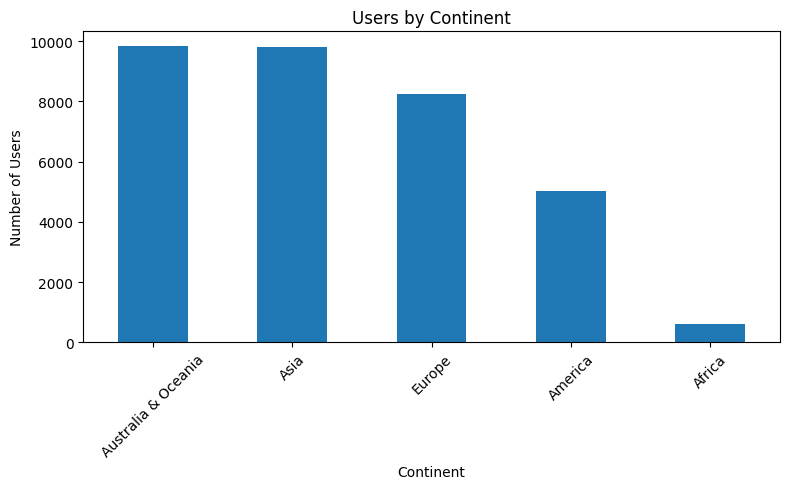

In [7]:
users_by_continent = (
    final_df.groupby('Continent')['UserId']
    .nunique()
    .sort_values(ascending=False)
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
users_by_continent.plot(kind='bar')
plt.title('Users by Continent')
plt.xlabel('Continent')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ***Observation Report***

**Asia and Australia & Oceania** have the highest number of users, indicating these regions are the primary contributors to the platform’s user base.

**Europe** shows moderate user participation, while **America** has noticeably fewer users in comparison.

**Africa** has the lowest user count, suggesting limited engagement or lower representation from this continent.

## 2.***Users by Country***

This plot shows the distribution of Users across different Countries. It helps identify high-engagement countries and supports targeted marketing and localized travel recommendations.

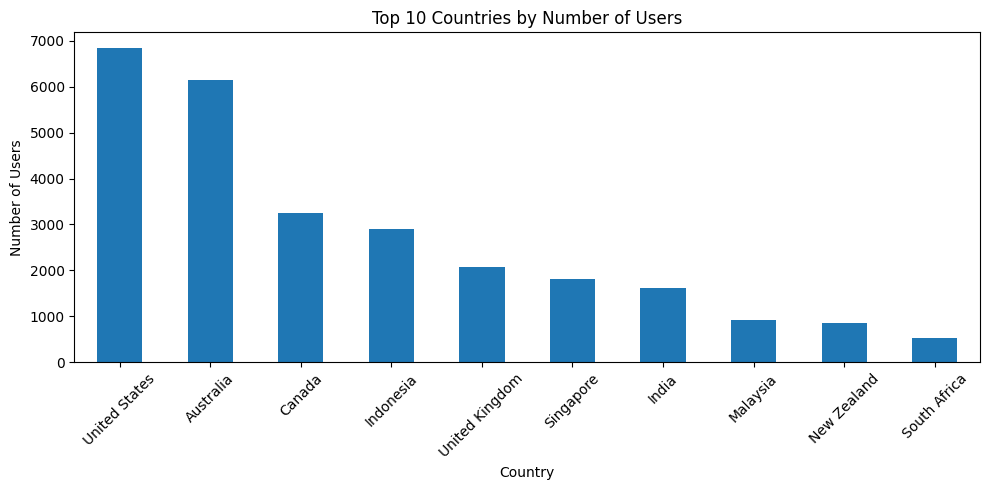

In [8]:
users_by_country = (
    final_df.groupby('Country')['UserId']
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
users_by_country.head(10).plot(kind='bar')
plt.title('Top 10 Countries by Number of Users')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ***Observation Report***

User distribution is heavily skewed toward **Asia and Australia & Oceania**, showing these regions dominate platform usage.

**Europe** has a substantial but comparatively lower number of users, while **America** shows moderate engagement.

**Africa** has minimal user representation, indicating a potential opportunity for future market expansion.

## 3.***Travel Patterns by Region (Number of Visits)***

This plot shows the number of tourist visits across different regions. It helps identify high-traffic regions and understand regional travel demand patterns for better planning and recommendations.

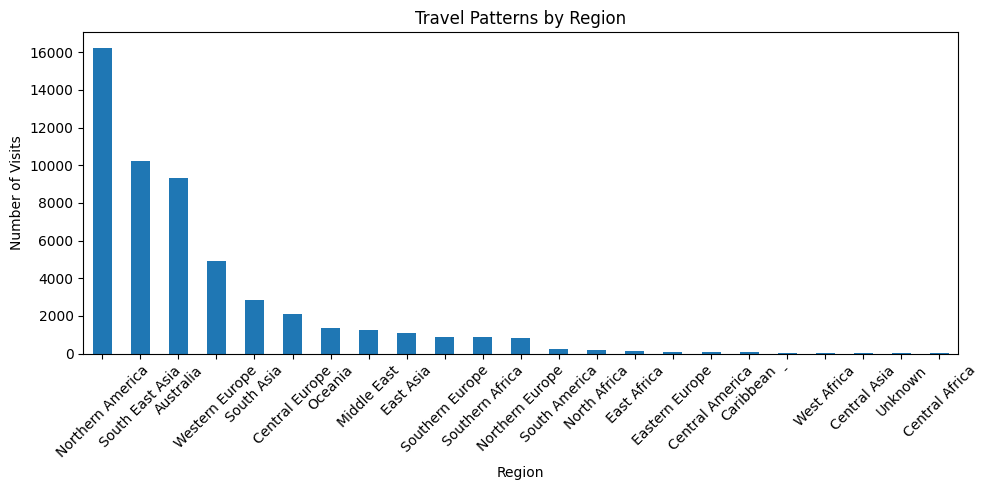

In [9]:
region_travel_patterns = (
    final_df.groupby('Region')['AttractionId']
    .count()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
region_travel_patterns.plot(kind='bar')
plt.title('Travel Patterns by Region')
plt.xlabel('Region')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ***Observation Report***

Travel activity is highly concentrated in **Northern America, South East Asia, and Australia**, indicating these regions dominate overall visits.

**Western Europe and South Asia** show moderate travel volumes, suggesting consistent but secondary travel demand.

**Several regions (e.g., Central Africa, West Africa, Unknown)** have very low visit counts, highlighting uneven regional engagement and potential data sparsity.

## **4.2 Attraction Insights**

Attraction analysis helps identify which attractions are most popular and which types receive the highest ratings. These insights reveal user preferences, demand patterns, and high-performing attraction categories, which are valuable for recommendations, marketing, and strategic planning.

## 1.***Most Visited Attractions (Top 10)***

This plot shows the top 10 most visited Attractions. It helps identify popular destinations and supports recommendation and promotion strategies based on user interest trends.

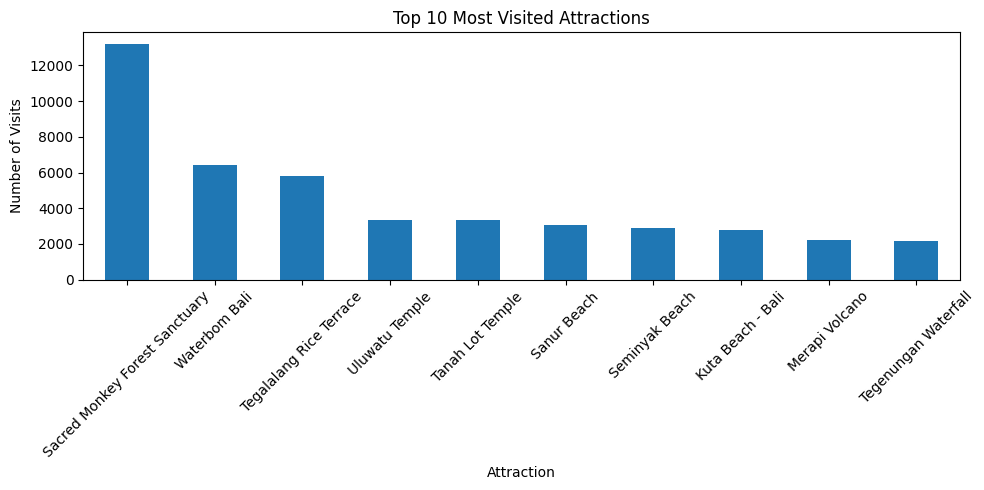

In [10]:
most_visited_attractions = (
    final_df.groupby('Attraction')['AttractionId']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
most_visited_attractions.plot(kind='bar')
plt.title('Top 10 Most Visited Attractions')
plt.xlabel('Attraction')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ***Observation Report***

A small set of attractions accounts for a large share of visits, indicating highly concentrated tourist interest.

Sacred Monkey Forest Sanctuary stands out as the most visited attraction by a significant margin.

Many top attractions are clustered in Bali, highlighting it as a major tourism hotspot in the dataset.

## 2.***Highest-Rated Attraction Types***

This plot shows the attraction types with the highest average ratings. It helps identify the kinds of experiences users prefer most, supporting better recommendation and tourism planning decisions.

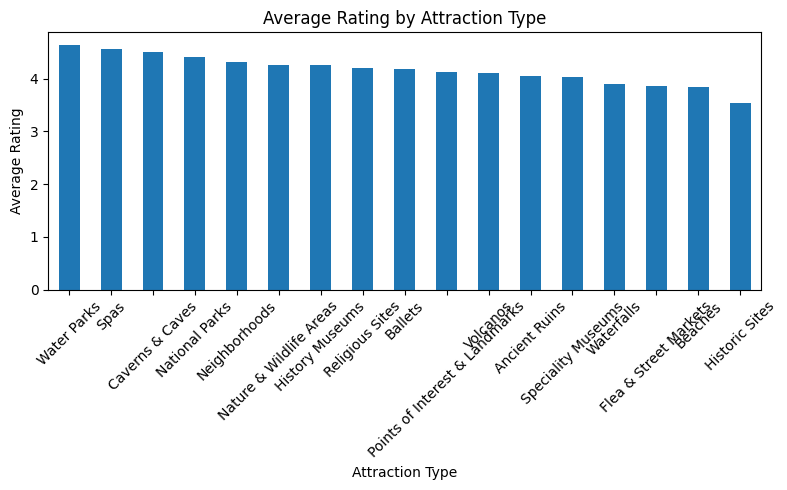

In [11]:
highest_rated_types = (
    final_df.groupby('AttractionType')['Rating']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
highest_rated_types.plot(kind='bar')
plt.title('Average Rating by Attraction Type')
plt.xlabel('Attraction Type')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ***Observation Report***

Nature-focused attractions like water **parks, spas, and caves** receive the highest average ratings, indicating strong visitor satisfaction.

**Cultural and historical categories (museums, religious sites, ancient ruins)** maintain consistently good ratings but slightly lower than nature-based ones.

**Historic sites and flea & street markets** show comparatively lower average ratings, suggesting scope for experience improvement.

## **4.3 Visit Mode Analysis**

Visit mode analysis helps understand how users prefer to travel and how these preferences vary across user demographics and time. By studying visit modes across regions and seasons, we can identify behavioral patterns that support targeted recommendations and personalized experiences.

## 1.***Visit Mode vs Geography (Region)***

This plot compares different visit modes across regions. It helps understand how travel preferences vary geographically, enabling region-specific packages and targeted recommendations.

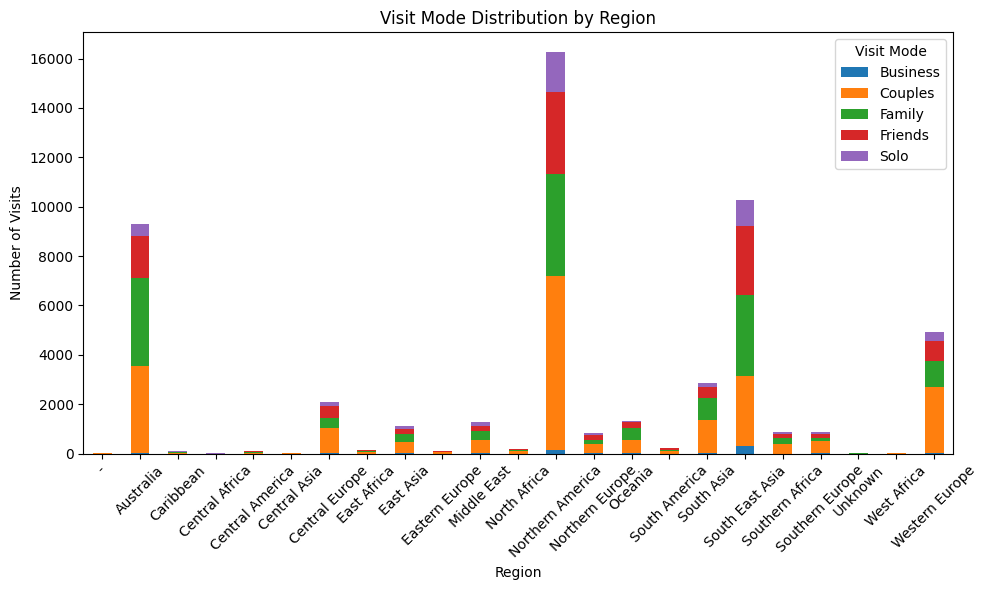

In [12]:
visitmode_by_region = (
    final_df.groupby(['Region', 'VisitMode'])
    .size()
    .unstack()
    .fillna(0)
)

visitmode_by_region.plot(kind='bar', figsize=(10, 6), stacked=True)

plt.title('Visit Mode Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45)
plt.legend(title='Visit Mode')
plt.tight_layout()
plt.show()

## ***Observation Report***

**Couples and Family** visits dominate across most regions, especially in high-traffic areas.

**Friends** travel is consistently strong, while **Solo** and **Business travel** remain comparatively low.

**This indicates leisure-focused tourism across regions.**

## 2.***Visit Mode vs Season***

This plot shows how different visit modes vary across seasons. It helps identify seasonal travel behavior and supports planning of season-specific tourism offerings and promotions.

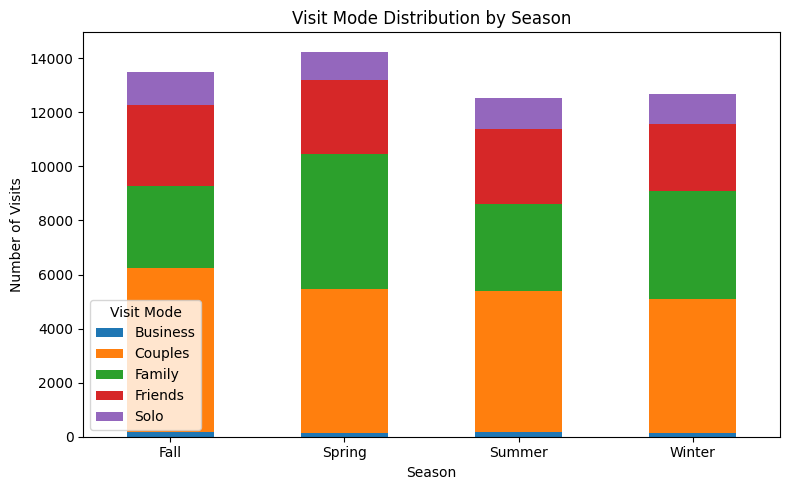

In [13]:
visitmode_by_season = (
    final_df.groupby(['season', 'VisitMode'])
    .size()
    .unstack()
    .fillna(0)
)

visitmode_by_season.plot(kind='bar', stacked=True, figsize=(8, 5))

plt.title('Visit Mode Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Number of Visits')
plt.xticks(rotation=0)
plt.legend(title='Visit Mode')
plt.tight_layout()
plt.show()

## ***Observation Report***

**Spring and Fall** see the highest overall travel volume across all visit modes.

**Couples and Family** travel peak during these seasons.

**Seasonality** clearly influences travel behavior more than visit purpose.

## 3.***Visit Mode vs Month***

This plot shows how visit modes change across different months. It helps identify monthly travel trends and supports time-based marketing and demand forecasting.

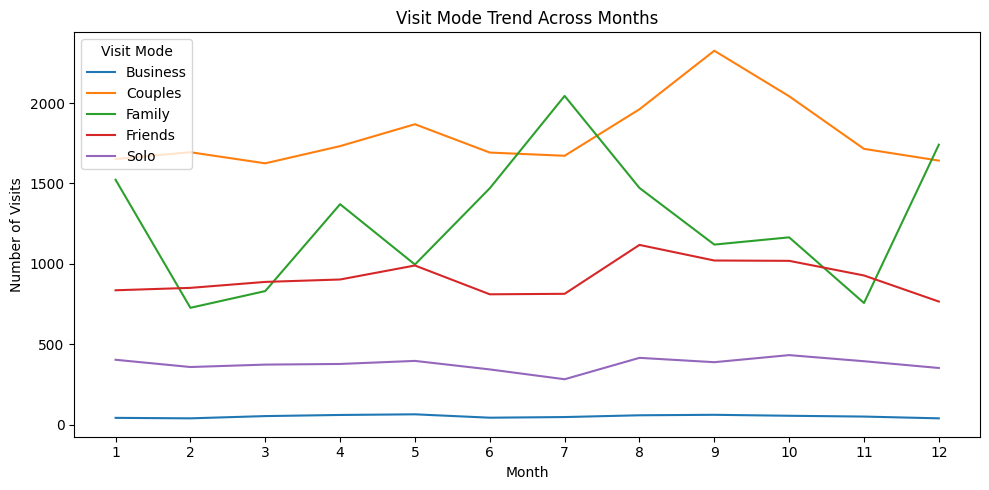

In [14]:
visitmode_by_month = (
    final_df.groupby(['VisitMonth', 'VisitMode'])
    .size()
    .unstack()
    .fillna(0)
)

visitmode_by_month.plot(kind='line', figsize=(10, 5))

plt.title('Visit Mode Trend Across Months')
plt.xlabel('Month')
plt.ylabel('Number of Visits')
plt.xticks(range(1, 13))
plt.legend(title='Visit Mode')
plt.tight_layout()
plt.show()

## ***Observation Report***

**Couples and Family** travel show strong peaks in mid-year and early fall months.

**Friends travel** rises during vacation-heavy periods.

**Business travel** remains low and stable throughout the year.

## **4.4 Ratings Analysis**

Ratings reflect user satisfaction and are a key signal for evaluating attraction quality and overall travel experience. Analyzing rating distributions and regional trends helps identify high-performing destinations and areas needing improvement.

## 1.***Rating Distribution***

This plot shows the overall distribution of user ratings across attractions. It helps understand general user satisfaction levels and detect rating patterns or biases in the data.

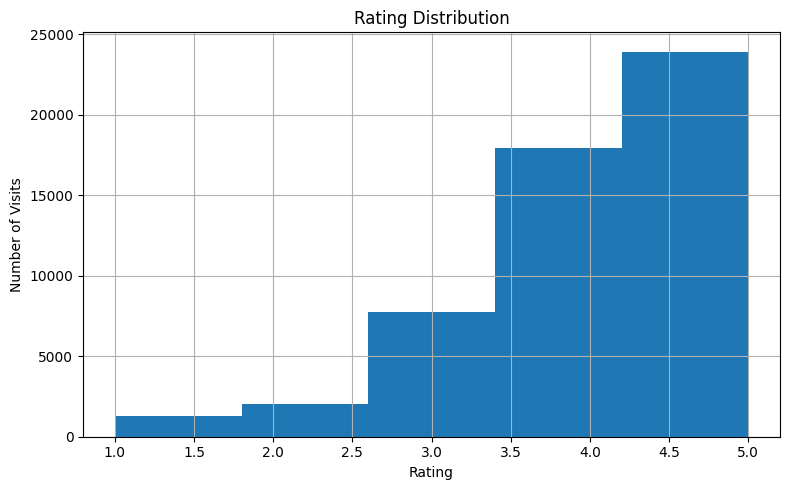

In [15]:
plt.figure(figsize=(8, 5))
final_df['Rating'].hist(bins=5)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Visits')
plt.tight_layout()
plt.show()

## ***Observation Report***

**Skew toward higher ratings:** The distribution is heavily concentrated between 3.5 and 5.0, indicating that most users tend to give positive ratings.

**Low frequency of poor ratings:** Ratings below 2.5 occur very infrequently, suggesting relatively high overall user satisfaction.

**Peak around 4–4.5 range:** The highest number of visits falls in the upper-mid rating bins, implying a generally favorable perception rather than extreme satisfaction or dissatisfaction.

## 2.***Average Rating by Region***

This plot shows the average attraction ratings for each region. It helps identify high- and low-performing regions, guiding targeted improvements and personalized recommendations.

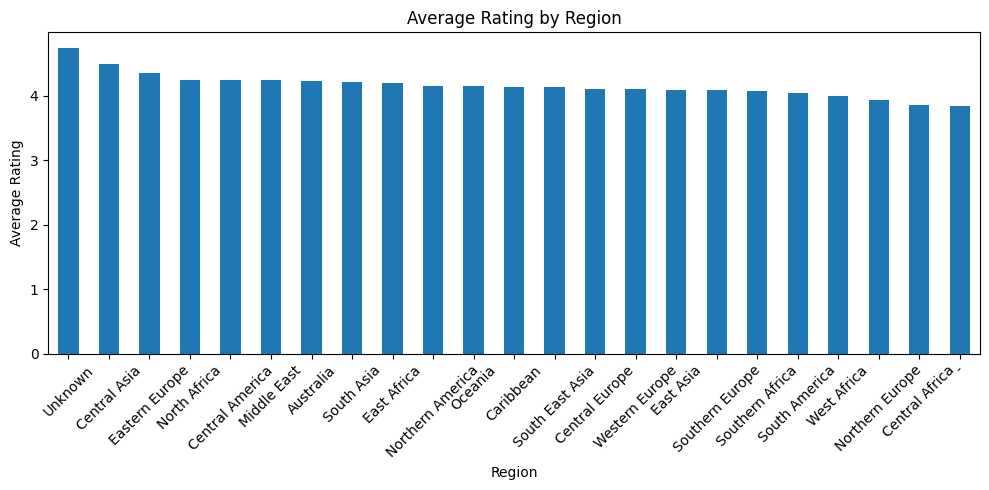

In [16]:
region_rating = (
    final_df.groupby('Region')['Rating']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
region_rating.plot(kind='bar')
plt.title('Average Rating by Region')
plt.xlabel('Region')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ***Observation Report***

**Limited regional variation:** Average ratings across regions are closely clustered between ~3.9 and 4.6, indicating consistent user experience globally.

**Highest ratings in ‘Unknown’ and Central Asia:** These regions show comparatively higher average ratings, suggesting better perceived quality or fewer negative experiences.

**Slightly lower ratings in African regions:** Central Africa and Northern Africa exhibit marginally lower averages, which may point to regional differences in service quality or user expectations.

# **Saving the Dataset**

In [17]:
# Saving the original dataset before encoding and scaling to be used for classification
# Save the cleaned dataset as a CSV, we only save first 100 rows because the ML model might crash with larger datasets
final_df.to_csv(
    '../dataset/cleaned_tourism_data.csv',
    index=False
)

print("Saveing the dataset successfully in the 'data' folder.")

Saveing the dataset successfully in the 'data' folder.
